# J fitting

图表已保存至: D:\hfh experiment_lab\data\Cal_J1\20260120Cal_J1-8\FigS8.pdf


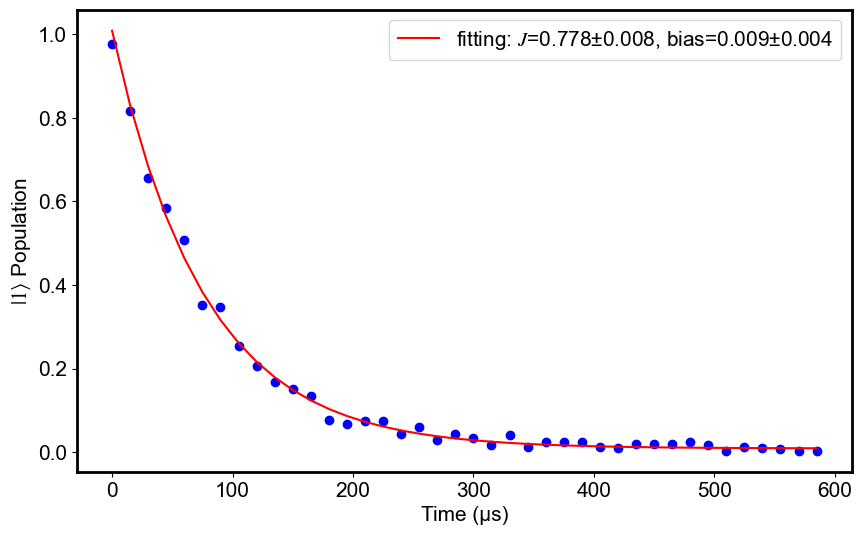

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 负号显示 参数设置
Gamma_0 = 19.6 * 2 * np.pi
Gamma_1 = 19.6 * 2 * np.pi / 3
def load_csv_data(filepath):
    """加载CSV文件（自动处理路径），返回时间和P1数据"""
    try:
        # 统一路径格式（兼容Windows/Linux）
        filepath = os.path.normpath(filepath)
        # 验证文件是否存在
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"文件不存在: {filepath}")
        df = pd.read_csv(filepath, header=None)
        return df.iloc[:, 0].values, df.iloc[:, 1].values
    except Exception as e:
        print(f"错误: {str(e)}")
        return None, None
# 方式1：绝对路径（推荐）
csv_path = r'D:\hfh experiment_lab\data\Cal_J1\20260120Cal_J1-8\20260120Cal_J1-8.csv'  # 替换为您的实际路径

# 加载数据
time, p1 = load_csv_data(csv_path)
if time is None:
    raise RuntimeError('数据加载失败')
data = np.column_stack((time, p1))
# 定义拟合函数，增加 bias
def fit_func(x, J, bias):
    return np.exp(-4 * J**2 * (Gamma_0 - Gamma_1) * x / Gamma_0**2) + bias
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'figure.titlesize': 15,
    'font.family': 'serif',
    'font.serif': ['Arial', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 2,
    'grid.alpha': 0.3
})
# 执行拟合与可视化
try:
    popt, pcov = curve_fit(fit_func, data[:, 0], data[:, 1], p0=[0.4, 0.0], maxfev=10000)
    JFit, biasFit = popt
    JFit_error, biasFit_error = np.sqrt(np.diag(pcov))
    # 计算R-squared
    residuals = data[:, 1] - fit_func(data[:, 0], JFit, biasFit)
    r_squared = 1 - (np.sum(residuals**2) / np.sum((data[:, 1] - np.mean(data[:, 1]))**2))
    # 可视化
    plt.figure(figsize=(10, 6))
    plt.scatter(data[:, 0], data[:, 1], color='blue')
    plt.plot(data[:, 0], fit_func(data[:, 0], JFit, biasFit), 
             'r-', label=f'fitting: $J$={JFit:.3f}±{JFit_error:.3f}, bias={biasFit:.3f}±{biasFit_error:.3f}')
    plt.xlabel('Time (μs)')
    plt.ylabel(r'$|1\rangle$ Population')
    # plt.title(r'\gamma fitting', fontsize=14)
    plt.legend()
    # plt.grid(True)
    # 自动保存到CSV同目录
    output_dir = os.path.dirname(csv_path)
    plot_path = os.path.join(output_dir, "FigS8.pdf")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"图表已保存至: {plot_path}")
    plt.show()
    # 打印报告
    # print("\n" + "="*50)
    # print(f"{'参数':<10}{'值':<20}{'误差':<20}")
    # print(f"{'J':<10}{JFit:.6f}{JFit_error:.6f}")
    # print(f"{'bias':<10}{biasFit:.6f}{biasFit_error:.6f}")
    # print(f"{'R²':<10}{r_squared:.6f}")
    # print("="*50)
except Exception as e:
    print(f"拟合失败: {str(e)}")

In [4]:
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'figure.titlesize': 15,
    'font.family': 'serif',
    'font.serif': ['Arial', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 2,
    'grid.alpha': 0.3
})

J1 calibration

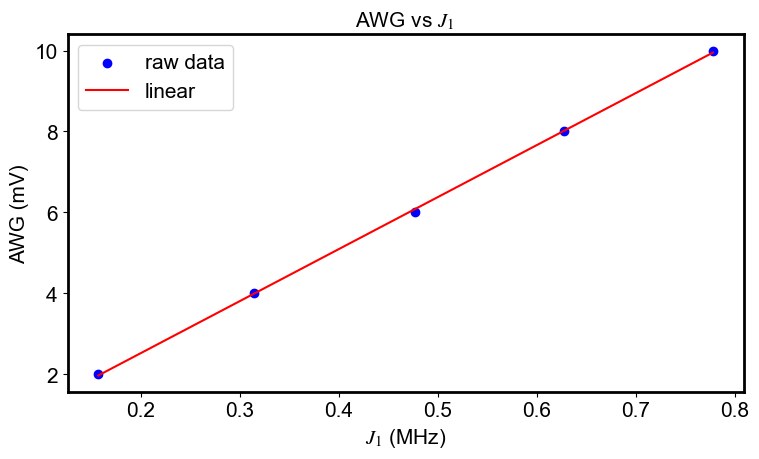

In [22]:
import numpy as np
import matplotlib.pyplot as plt
AWG_list=[2,4,6,8,10]

Jlist=[0.1572,0.3146,0.4773,0.6273,0.7779]

J_arr = np.array(Jlist)
AWG_arr = np.array(AWG_list)


coeffs = np.polyfit(J_arr, AWG_arr, 1)
poly4 = np.poly1d(coeffs)
J_fit = np.linspace(min(J_arr), max(J_arr), 200)
AWG_fit = poly4(J_fit)

# 画图
plt.figure(figsize=(8, 5))
plt.scatter(J_arr, AWG_arr, color='b', label='raw data')
plt.plot(J_fit, AWG_fit, 'r-', label='linear')
plt.xlabel(r'$J_1$ (MHz)')
plt.ylabel('AWG (mV)')
plt.title(r'AWG vs $J_1$ ')
# plt.grid(True)
plt.legend()
plt.savefig('FigS9A.svg', dpi=300, bbox_inches='tight')  # 保存图像
plt.tight_layout()
plt.show()

# print("1阶多项式系数（高次到低次）:", coeffs)

J2 calibration

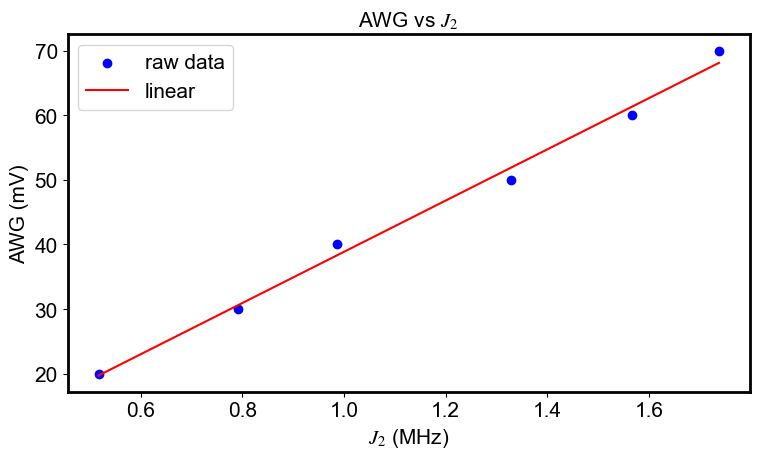

In [23]:
import numpy as np
import matplotlib.pyplot as plt

AWG_list=[20,30,40,50,60,70]
J2list=[0.517,0.791,0.987,1.329,1.567,1.738]


J_arr = np.array(J2list)
AWG_arr = np.array(AWG_list)


coeffs = np.polyfit(J_arr, AWG_arr, 1)
poly4 = np.poly1d(coeffs)
J_fit = np.linspace(min(J_arr), max(J_arr), 200)
AWG_fit = poly4(J_fit)

# 画图
plt.figure(figsize=(8, 5))
plt.scatter(J_arr, AWG_arr, color='b', label='raw data')
plt.plot(J_fit, AWG_fit, 'r-', label='linear')
plt.xlabel(r'$J_2$ (MHz)')
plt.ylabel('AWG (mV)')
plt.title(r'AWG vs $J_2$ ')
# plt.grid(True)
plt.legend()
plt.savefig('FigS9B.svg', dpi=300, bbox_inches='tight')  # 保存图像
plt.tight_layout()
plt.show()
